# Bayesian Analysis

In [1]:
from base.preprocessing import preprocess_all

from base.frequentist.models import fit_arima_model, expanding_window_forecast_arima

import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

## Preprocess

In [2]:
artifacts = preprocess_all(
    data_path="base/data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags= False,
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

target_col = "log_eui"


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

## ARIMA(2,0,1) vs AR(3)

## ARIMA(2,0,1)

In [3]:
# ===========================================
# Run ARIMA for ONE SET of PARAMETERS (p,d,q)
# ===========================================

y_train_arima = train_df[target_col]
y_test_arima = test_df[target_col]

# Choose the ARIMA order manually
order = (2, 0, 1)      # <-- put your numbers here
seasonal_order = (0, 0, 0, 0)

print(f"\n=== Fitting ARIMA{order} on {target_col} ===")

# ---- Fit model ----
res = fit_arima_model(
    y=y_train_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=False,
)


=== Fitting ARIMA(2, 0, 1) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive para


### Residuals

In [4]:
arima_201_resid_in = res.resid.dropna()

arima_201_resid_in.name = "arima_201_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_201_resid_in.head())

arima_201_model = res


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -0.794627
1996-02-01   -0.210639
1996-03-01   -0.752071
1996-04-01   -0.044157
1996-05-01    0.742413
Name: arima_201_resid_in, dtype: float64


### Forecasts

In [5]:
# ===========================================
# 1-step-ahead EXPANDING-WINDOW forecasts
# ===========================================

print("\n=== 1-step-ahead expanding-window forecasts on TEST sample ===")

arima_201_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=False,
)


=== 1-step-ahead expanding-window forecasts on TEST sample ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive para


### ---- OOS errors ----

In [6]:
arima_201_errors_oos = (y_test_arima - arima_201_forecast).dropna()
arima_201_errors_oos.name = "arima_201_errors_oos"

rmse = float(np.sqrt(np.mean(arima_201_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nHEAD of 1-step expanding-window forecast errors:")
print(arima_201_errors_oos.head())


RMSE (1-step expanding window): 0.2732789956280201

HEAD of 1-step expanding-window forecast errors:
date
2018-05-01   -0.042559
2018-06-01    0.251525
2018-07-01    0.193393
2018-08-01    0.086241
2018-09-01    0.009668
Name: arima_201_errors_oos, dtype: float64


## Bayesian AR(3)

In [7]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import pacf
import warnings
warnings.filterwarnings("ignore")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [8]:
# Checks for informed prior choice

y_train_ar = train_df[target_col]
y_test_ar  = test_df[target_col]
y_train_np = y_train_ar.values.astype(float)

# Compute the values from ARIMA(3,0,0) for informed priors
arima_300_model = fit_arima_model(
    y=y_train_arima,
    order=(3, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=True,
    enforce_invertibility=False,
)

# Choose phi1 and phi2 with the PACF value at lag 1 (frequentist_original)
pacf_vals = pacf(y_train_ar, nlags=3)
informed_phi1 = pacf_vals[1]
informed_phi2 = pacf_vals[2]
informed_phi3 = pacf_vals[3]

# Check the Standard Deviation of ARIMA and use it as sigma
informed_sigma_scale = arima_300_model.resid.std()

# Prior Predictive Check involves simulating data using only your priors, before looking at the actual observations.
# use pm.sample_prior_predictive()

# Check the long-term trend for c
informed_c_mean = y_train_ar.mean()

# This represents the Frequentist uncertainty about phis
informed_phi1_sigma = arima_300_model.bse["ar.L1"]
informed_phi2_sigma = arima_300_model.bse["ar.L2"]
informed_phi3_sigma = arima_300_model.bse["ar.L3"]

print(f"Informed c (mean): {informed_c_mean:.4f}")
print(f"Informed phi1 (mu): {informed_phi1:.4f}, phi2 (mu): {informed_phi2:.4f}")
print(f"Informed sigma (scale): {informed_sigma_scale:.4f}")
print(f"Informed phi1 sigma (uncertainty): {informed_phi1_sigma:.4f}")
print(f"Informed phi2 sigma (uncertainty): {informed_phi2_sigma:.4f}")
print(f"Informed phi3 sigma (uncertainty): {informed_phi3_sigma:.4f}")

Informed c (mean): -0.2076
Informed phi1 (mu): 0.6856, phi2 (mu): 0.3044
Informed sigma (scale): 0.5101
Informed phi1 sigma (uncertainty): 0.0307
Informed phi2 sigma (uncertainty): 0.0409
Informed phi3 sigma (uncertainty): 0.0347


In [9]:
with pm.Model() as informed_ar3_model:
    # --- Informed Priors ---
    c     = pm.Normal("c",     mu=informed_c_mean,   sigma=0.5)
    phi1  = pm.Normal("phi1",  mu=informed_phi1,     sigma=informed_phi1_sigma)
    phi2  = pm.Normal("phi2",  mu=informed_phi2,     sigma=informed_phi2_sigma)
    phi3  = pm.Normal("phi3",  mu=informed_phi3,     sigma=informed_phi3_sigma)
    sigma = pm.HalfNormal("sigma", sigma=informed_sigma_scale)

    # Degrees of freedom (nu) for tail behavior
    # Large nu = Normal tails; Small nu = Fat tails.
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    # --- Likelihood (Model Structure) ---
    # We define the likelihood so the prior predictive check can simulate observations.
    mu = c + phi1 * y_train_np[2:-1] + phi2 * y_train_np[1:-2] + phi3 * y_train_np[0:-3]
    obs = pm.StudentT("obs", nu=nu, mu=mu, sigma=sigma, observed=y_train_np[3:])


Sampling: [c, nu, obs, phi1, phi2, phi3, sigma]


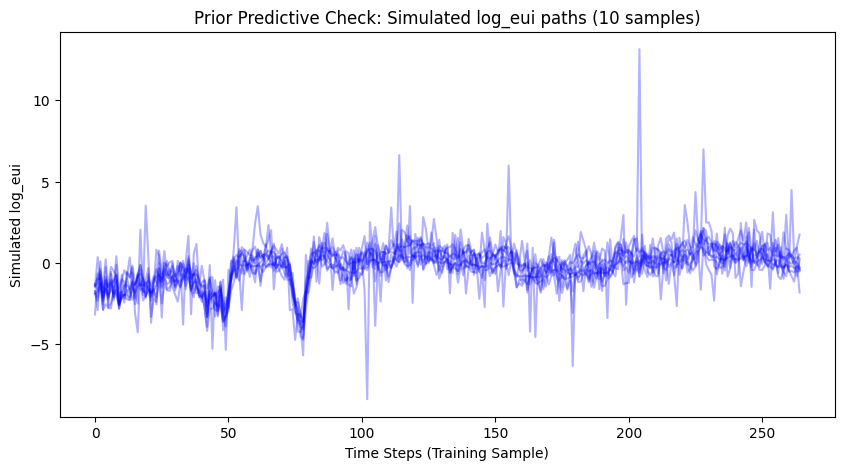

In [10]:
# --- 4. Prior Predictive Check ---
with informed_ar3_model:
    prior_pc = pm.sample_prior_predictive(samples=500, random_seed=6)

plt.figure(figsize=(10, 5))

# Plot the simulated 'obs' data from the priors
# This allows you to check if the range of log_eui stays physically plausible.
for i in range(10):
    plt.plot(prior_pc.prior_predictive["obs"][0, i, :], color="blue", alpha=0.3)

plt.title("Prior Predictive Check: Simulated log_eui paths (10 samples)")
plt.xlabel("Time Steps (Training Sample)")
plt.ylabel("Simulated log_eui")
plt.show()

now we implement the MCMC

In [11]:
with informed_ar3_model:
    # We use NUTS sampling to explore the posterior distribution
    idata_informed = pm.sample(
        draws=1000,
        tune=500,
        chains=4,
        target_accept=0.9,
        random_seed=6,
        progressbar=True
    )

# --- Extract posterior draws for future cells ---
post_inf = idata_informed.posterior
c_draws    = post_inf["c"].values.flatten()
phi1_draws = post_inf["phi1"].values.flatten()
phi2_draws = post_inf["phi2"].values.flatten()
phi3_draws = post_inf["phi3"].values.flatten()
sigma_draws = post_inf["sigma"].values.flatten()

print("Informed model sampling complete and draws extracted.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma, nu]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 912 seconds.


Informed model sampling complete and draws extracted.


Convergence Diagnostics
You must check if the NUTS sampler actually converged on a stable solution. If the chains didn't "mix" well, your forecasts will be unreliable.
1. R-hat ($\hat{R}$): Should be extremely close to 1.00.
2. ESS (Effective Sample Size): Should ideally be $> 400$ per chain to ensure you have enough independent samples.
3. Trace Plots: You want to see "fuzzy caterpillars," not distinct lines or trends.

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c      0.007  0.016  -0.023    0.038        0.0    0.000    4538.0    2835.0   
phi1   0.596  0.025   0.546    0.640        0.0    0.000    4581.0    2992.0   
phi2   0.174  0.032   0.115    0.235        0.0    0.001    4573.0    2924.0   
phi3   0.218  0.030   0.165    0.276        0.0    0.000    4891.0    2870.0   
sigma  0.193  0.018   0.160    0.226        0.0    0.000    3861.0    2935.0   

       r_hat  
c        1.0  
phi1     1.0  
phi2     1.0  
phi3     1.0  
sigma    1.0  


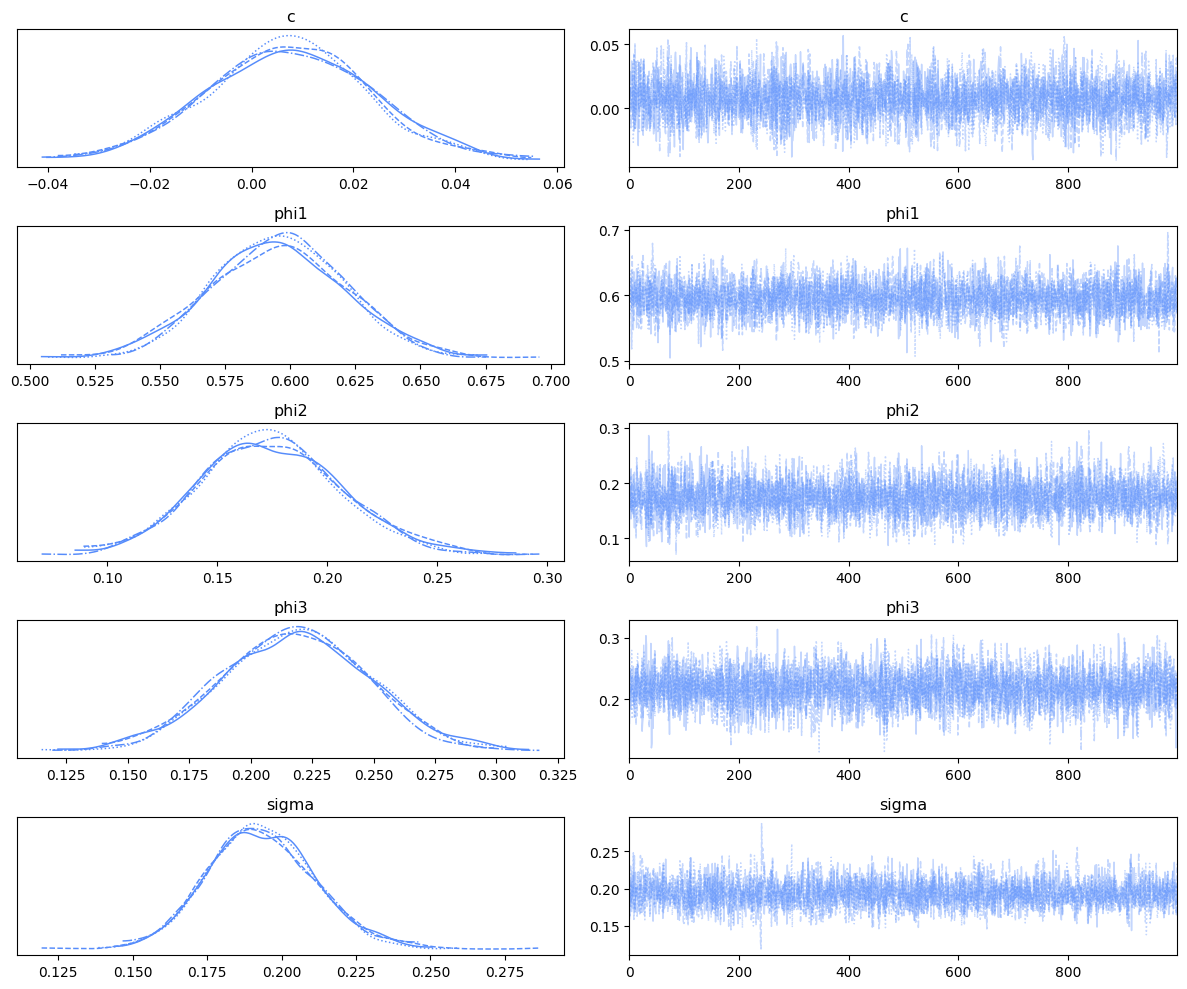

In [12]:
# Check the numbers
print(az.summary(idata_informed, var_names=["c", "phi1", "phi2", "phi3", "sigma"]))

# Check the visuals
az.plot_trace(idata_informed, var_names=["c", "phi1", "phi2", "phi3", "sigma"])
plt.tight_layout()
plt.show()

Sampling: [obs]


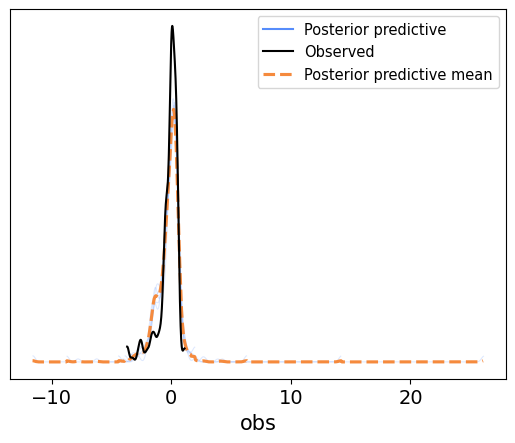

In [13]:
with informed_ar3_model:
    # Generate data from the POSTERIOR
    ppc = pm.sample_posterior_predictive(idata_informed)

# Plot the real data vs. the model's version
az.plot_ppc(ppc, num_pp_samples=5)
plt.show()

In [14]:
# 1. Calculate point estimates (Posterior Means)
c_pm     = float(post_inf["c"].values.mean())
phi1_pm  = float(post_inf["phi1"].values.mean())
phi2_pm  = float(post_inf["phi2"].values.mean())
phi3_pm  = float(post_inf["phi3"].values.mean())
sigma_pm = float(post_inf["sigma"].values.mean())

mu_in = (c_pm +
         phi1_pm * y_train_np[2:-1] +
         phi2_pm * y_train_np[1:-2] +
         phi3_pm * y_train_np[0:-3])

# 3. Calculate residuals (Actual - Predicted)
# We align with the target starting at index 3
resid_in = y_train_np[3:] - mu_in

# 4. Diagnostics: Ljung-Box check
lb_results = acorr_ljungbox(resid_in, lags=[1, 2, 3, 12, 24, 36], return_df=True)
print("Ljung-Box Test on AR(3) Residuals:")
print(lb_results)

Ljung-Box Test on AR(3) Residuals:
       lb_stat     lb_pvalue
1     5.569033  1.828085e-02
2     5.680273  5.841769e-02
3    10.659576  1.371657e-02
12   90.101079  4.719844e-14
24  107.482915  1.547469e-12
36  160.266677  1.300366e-17


### Expanding window

In [15]:
# ---- Configuration for Speed ----
REFIT_EVERY = 6  # Only run NUTS every N months
EW_DRAWS    = 200 # Reduced draws for speed during the loop
EW_TUNE     = 100  # Reduced tuning steps
EW_CHAINS   = 4

# Prepare data arrays
y_full_np     = artifacts["features_df"][target_col].values.astype(float)
train_end_loc = artifacts["features_df"].index.get_loc(y_train_ar.index[-1])
n_test_ew     = len(y_test_ar)

# Output containers
ew_point  = np.full(n_test_ew, np.nan)
ew_hdi_lo = np.full(n_test_ew, np.nan)
ew_hdi_hi = np.full(n_test_ew, np.nan)

# Initialize with your "Informed" draws from the first sampler
_c_draws, _phi1_draws, _phi2_draws, _phi3_draws = c_draws, phi1_draws, phi2_draws, phi3_draws

print(f"Running {n_test_ew} steps (Refitting every {REFIT_EVERY} months)...")

for step in range(n_test_ew):
    # Current window ends at the day before the forecast target
    win_end = train_end_loc + step + 1
    y_win   = y_full_np[:win_end]

    # 1. Periodic Refit: Update the parameters with the new data
    if step % REFIT_EVERY == 0 and step > 0:
        with pm.Model() as _ew_model:
            # Use current posterior means as the center for new priors (Informed Warm-start)
            c_e  = pm.Normal("c",    mu=_c_draws.mean(),    sigma=0.3)
            p1   = pm.Normal("phi1", mu=_phi1_draws.mean(), sigma=0.1)
            p2   = pm.Normal("phi2", mu=_phi2_draws.mean(), sigma=0.1)
            p3   = pm.Normal("phi3", mu=_phi3_draws.mean(), sigma=0.1)
            s_e  = pm.HalfNormal("sigma", sigma=informed_sigma_scale)

            # Likelihood for AR(3)
            mu_win = c_e + p1*y_win[2:-1] + p2*y_win[1:-2] + p3*y_win[0:-3]
            pm.Normal("obs", mu=mu_win, sigma=s_e, observed=y_win[3:])

            # Fast sampling
            _trace = pm.sample(draws=EW_DRAWS, tune=EW_TUNE, chains=EW_CHAINS,
                               progressbar=False, random_seed=step)

            # Update the draws for the next steps
            _c_draws    = _trace.posterior["c"].values.flatten()
            _phi1_draws = _trace.posterior["phi1"].values.flatten()
            _phi2_draws = _trace.posterior["phi2"].values.flatten()
            _phi3_draws = _trace.posterior["phi3"].values.flatten()

        print(f"  [Refit] Month {step+1}/{n_test_ew} complete.")

    # 2. 1-Step Ahead Forecast
    # Use the most recent posterior draws to predict the next point
    # y[t] = c + phi1*y[t-1] + phi2*y[t-2] + phi3*y[t-3]
    mu_step = (_c_draws +
               _phi1_draws * y_win[-1] +
               _phi2_draws * y_win[-2] +
               _phi3_draws * y_win[-3])

    hdi = az.hdi(mu_step, hdi_prob=0.94)
    ew_point[step]  = mu_step.mean()
    ew_hdi_lo[step] = hdi[0]
    ew_hdi_hi[step] = hdi[1]

# Wrap results in Series
ar3_bayes_ew_forecast = pd.Series(ew_point, index=y_test_ar.index, name="Bayes_AR3_EW")
print("\nExpanding window calculation complete.")

Running 67 steps (Refitting every 6 months)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 80 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


  [Refit] Month 7/67 complete.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 84 seconds.
Initializing NUTS using jitter+adapt_diag...


  [Refit] Month 13/67 complete.


...

  [Refit] Month 55/67 complete.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 95 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


  [Refit] Month 61/67 complete.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma]
Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 111 seconds.


  [Refit] Month 67/67 complete.

Expanding window calculation complete.


## Comparison

In [16]:
def compute_metrics(y_true, y_pred, label):
    err = (y_true - y_pred).dropna()
    return {
        "Model": label,
        "RMSE":  np.sqrt(np.mean(err**2)),
        "MAE":   np.mean(np.abs(err)),
        "Bias":  np.mean(err), # Positive = Under-predicting, Negative = Over-predicting
        "Var(Error)": np.var(err)
    }

# Ensure you are comparing the Expanding Window results
# Note: Align lengths if they differ due to lags
comparison_rows = [
    compute_metrics(np.exp(y_test_arima), np.exp(arima_201_forecast), "Freq ARIMA(2,0,1)"),
    compute_metrics(np.exp(y_test_ar), np.exp(ar3_bayes_ew_forecast), "Bayes AR(3)")
]

df_cmp = pd.DataFrame(comparison_rows).set_index("Model")
print("=== Point Forecast Quality Comparison ===")
print(df_cmp.round(6))

=== Point Forecast Quality Comparison ===
                       RMSE       MAE      Bias  Var(Error)
Model                                                      
Freq ARIMA(2,0,1)  0.352956  0.236415  0.093563    0.115824
Bayes AR(3)        0.353371  0.241133  0.071666    0.119735


Residual Adequacy (Ljung-Box Comparison)
A model is only "high quality" if its residuals are white noise.

In [17]:
# Compare Ljung-Box p-values side-by-side
# We want these to be ABOVE 0.05
lb_freq = acorr_ljungbox(arima_201_model.resid.dropna(), lags=[6, 12], return_df=True)
lb_bay  = acorr_ljungbox(resid_in, lags=[6, 12], return_df=True)

print("\n=== Residual Quality (p-values) ===")
print(f"Freq ARIMA(6): {lb_freq['lb_pvalue'].values}")
print(f"Bayes AR(3) (6): {lb_bay['lb_pvalue'].values}")


=== Residual Quality (p-values) ===
Freq ARIMA(6): [2.19970412e-10 2.07553530e-14]
Bayes AR(3) (6): [5.45597862e-10 4.71984378e-14]


Visual Comparison & Uncertainty Bands
This plot reveals if the Bayesian model is "honest" about its mistakes. Frequentist bands (Confidence Intervals) are often fixed-width, while Bayesian Credible Intervals (HDI) can expand when the model is genuinely confused by the data.

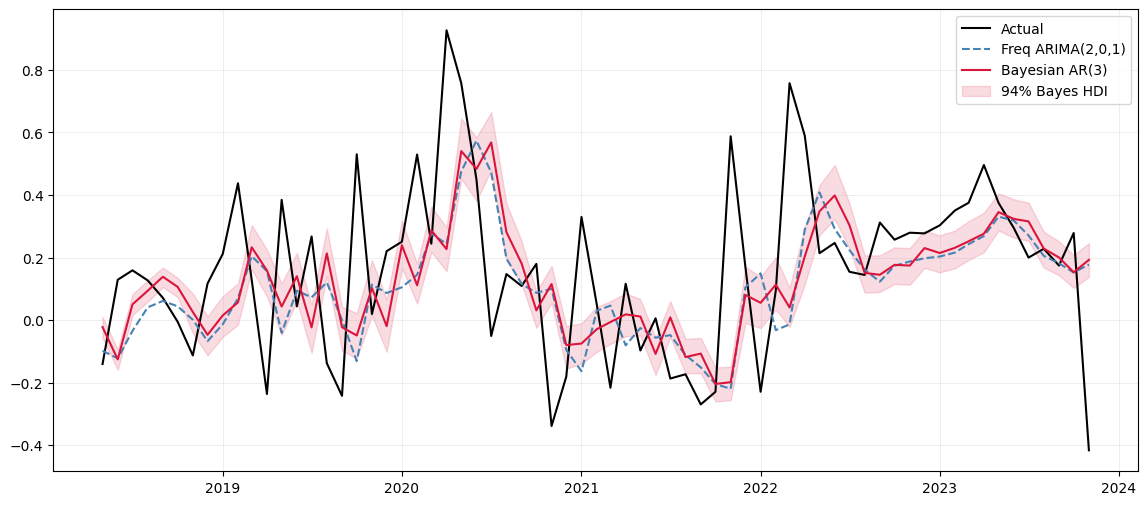

In [22]:
plt.figure(figsize=(14, 6))

# Plot actuals
plt.plot(y_test_ar.index, y_test_ar.values, color="black", label="Actual", linewidth=1.5)

# Plot Freq Forecast
plt.plot(y_test_arima.index, arima_201_forecast, color="steelblue",
         linestyle="--", label="Freq ARIMA(2,0,1)")

# Plot Bayes Forecast
plt.plot(y_test_ar.index, ar3_bayes_ew_forecast, color="crimson",
         label=f"Bayesian AR(3)")

# Bayesian Uncertainty (HDI)
# Use the 'ew_hdi_lo' and 'ew_hdi_hi' calculated during your EW loop
plt.fill_between(y_test_ar.index, ew_hdi_lo, ew_hdi_hi, color="crimson", alpha=0.15, label="94% Bayes HDI")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Stationary draws : 2,614 / 4,000  (65.3%)
Non-stationary   : 1,386  (34.7%)

Root moduli (all draws) — summary:
  Min  modulus : 0.9370  (danger zone: < 1.0)
  Mean modulus : 1.7681
  % roots < 1  : 11.55%


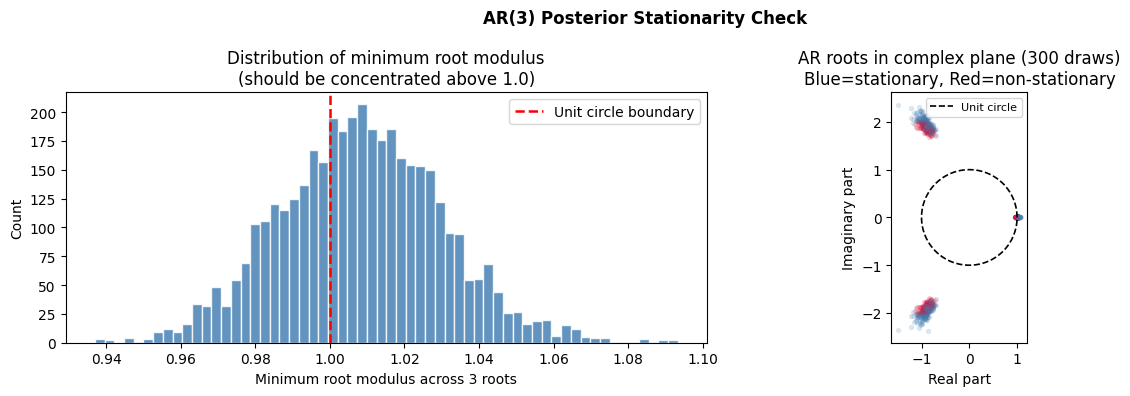


⚠  WARNING: more than 5% of draws are non-stationary.
   Consider re-running with enforce_stationarity=True,
   or filtering draws before forecasting.


In [19]:
# =============================================================================
# STATIONARITY CHECK — Bayesian AR(3) posterior draws
# =============================================================================
# Checks what fraction of posterior (phi1, phi2, phi3) draws imply a
# stationary process, i.e. all roots of 1 - phi1*z - phi2*z^2 - phi3*z^3 = 0
# lie strictly outside the unit circle.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

n_draws = len(phi1_draws)
is_stationary = np.zeros(n_draws, dtype=bool)
root_moduli    = np.zeros((n_draws, 3))  # modulus of each of the 3 roots

for i in range(n_draws):
    # numpy expects coefficients of z^0, z^1, z^2, z^3 for the companion poly
    # AR(3): 1 - phi1*z - phi2*z^2 - phi3*z^3 = 0
    # rearranged as polynomial in z: -phi3*z^3 - phi2*z^2 - phi1*z + 1 = 0
    coeffs = [-phi3_draws[i], -phi2_draws[i], -phi1_draws[i], 1.0]
    roots  = np.roots(coeffs)
    moduli = np.abs(roots)
    root_moduli[i]    = moduli
    is_stationary[i]  = np.all(moduli > 1.0)  # roots outside unit circle

pct_stationary = is_stationary.mean() * 100
print(f"Stationary draws : {is_stationary.sum():,} / {n_draws:,}  ({pct_stationary:.1f}%)")
print(f"Non-stationary   : {(~is_stationary).sum():,}  ({100 - pct_stationary:.1f}%)")
print(f"\nRoot moduli (all draws) — summary:")
print(f"  Min  modulus : {root_moduli.min():.4f}  (danger zone: < 1.0)")
print(f"  Mean modulus : {root_moduli.mean():.4f}")
print(f"  % roots < 1  : {(root_moduli < 1.0).mean()*100:.2f}%")

# ── Visual: histogram of minimum root modulus per draw ───────────────────────
min_modulus_per_draw = root_moduli.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(min_modulus_per_draw, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(1.0, color="red", lw=1.8, ls="--", label="Unit circle boundary")
ax.set_xlabel("Minimum root modulus across 3 roots")
ax.set_ylabel("Count")
ax.set_title("Distribution of minimum root modulus\n(should be concentrated above 1.0)")
ax.legend()

# ── Visual: scatter of roots in complex plane ─────────────────────────────────
ax = axes[1]
sample_idx = np.random.choice(n_draws, size=300, replace=False)
for i in sample_idx:
    coeffs = [-phi3_draws[i], -phi2_draws[i], -phi1_draws[i], 1.0]
    roots  = np.roots(coeffs)
    color  = "steelblue" if is_stationary[i] else "crimson"
    ax.scatter(roots.real, roots.imag, color=color, alpha=0.15, s=8)

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=1.2, label="Unit circle")
ax.set_aspect("equal")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")
ax.set_title("AR roots in complex plane (300 draws)\nBlue=stationary, Red=non-stationary")
ax.legend(fontsize=8)

fig.suptitle("AR(3) Posterior Stationarity Check", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

if pct_stationary < 95:
    print("\n⚠  WARNING: more than 5% of draws are non-stationary.")
    print("   Consider re-running with enforce_stationarity=True,")
    print("   or filtering draws before forecasting.")
else:
    print("\n✓  Stationarity satisfied in the vast majority of posterior draws.")

1. R-HAT AND EFFECTIVE SAMPLE SIZE
         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
c      0.0072  0.0160 -0.0229   0.0377     0.0002   0.0003  4538.1705   
phi1   0.5956  0.0253  0.5457   0.6401     0.0004   0.0004  4580.9346   
phi2   0.1742  0.0319  0.1146   0.2348     0.0005   0.0005  4572.7790   
phi3   0.2181  0.0299  0.1648   0.2765     0.0004   0.0005  4891.3201   
sigma  0.1932  0.0178  0.1597   0.2257     0.0003   0.0003  3861.0757   

        ess_tail   r_hat  
c      2835.4737  1.0011  
phi1   2992.1186  1.0018  
phi2   2923.5838  1.0016  
phi3   2869.7980  0.9999  
sigma  2935.0708  1.0035  

  Max R-hat  : 1.0035  (threshold ≤ 1.01 strict, ≤ 1.05 lenient)
  Min ESS    : 3861    (threshold ≥ 400 per chain)
  ✓ All R-hat values within acceptable range
  ✓ All ESS values above threshold

2. TRACE PLOTS


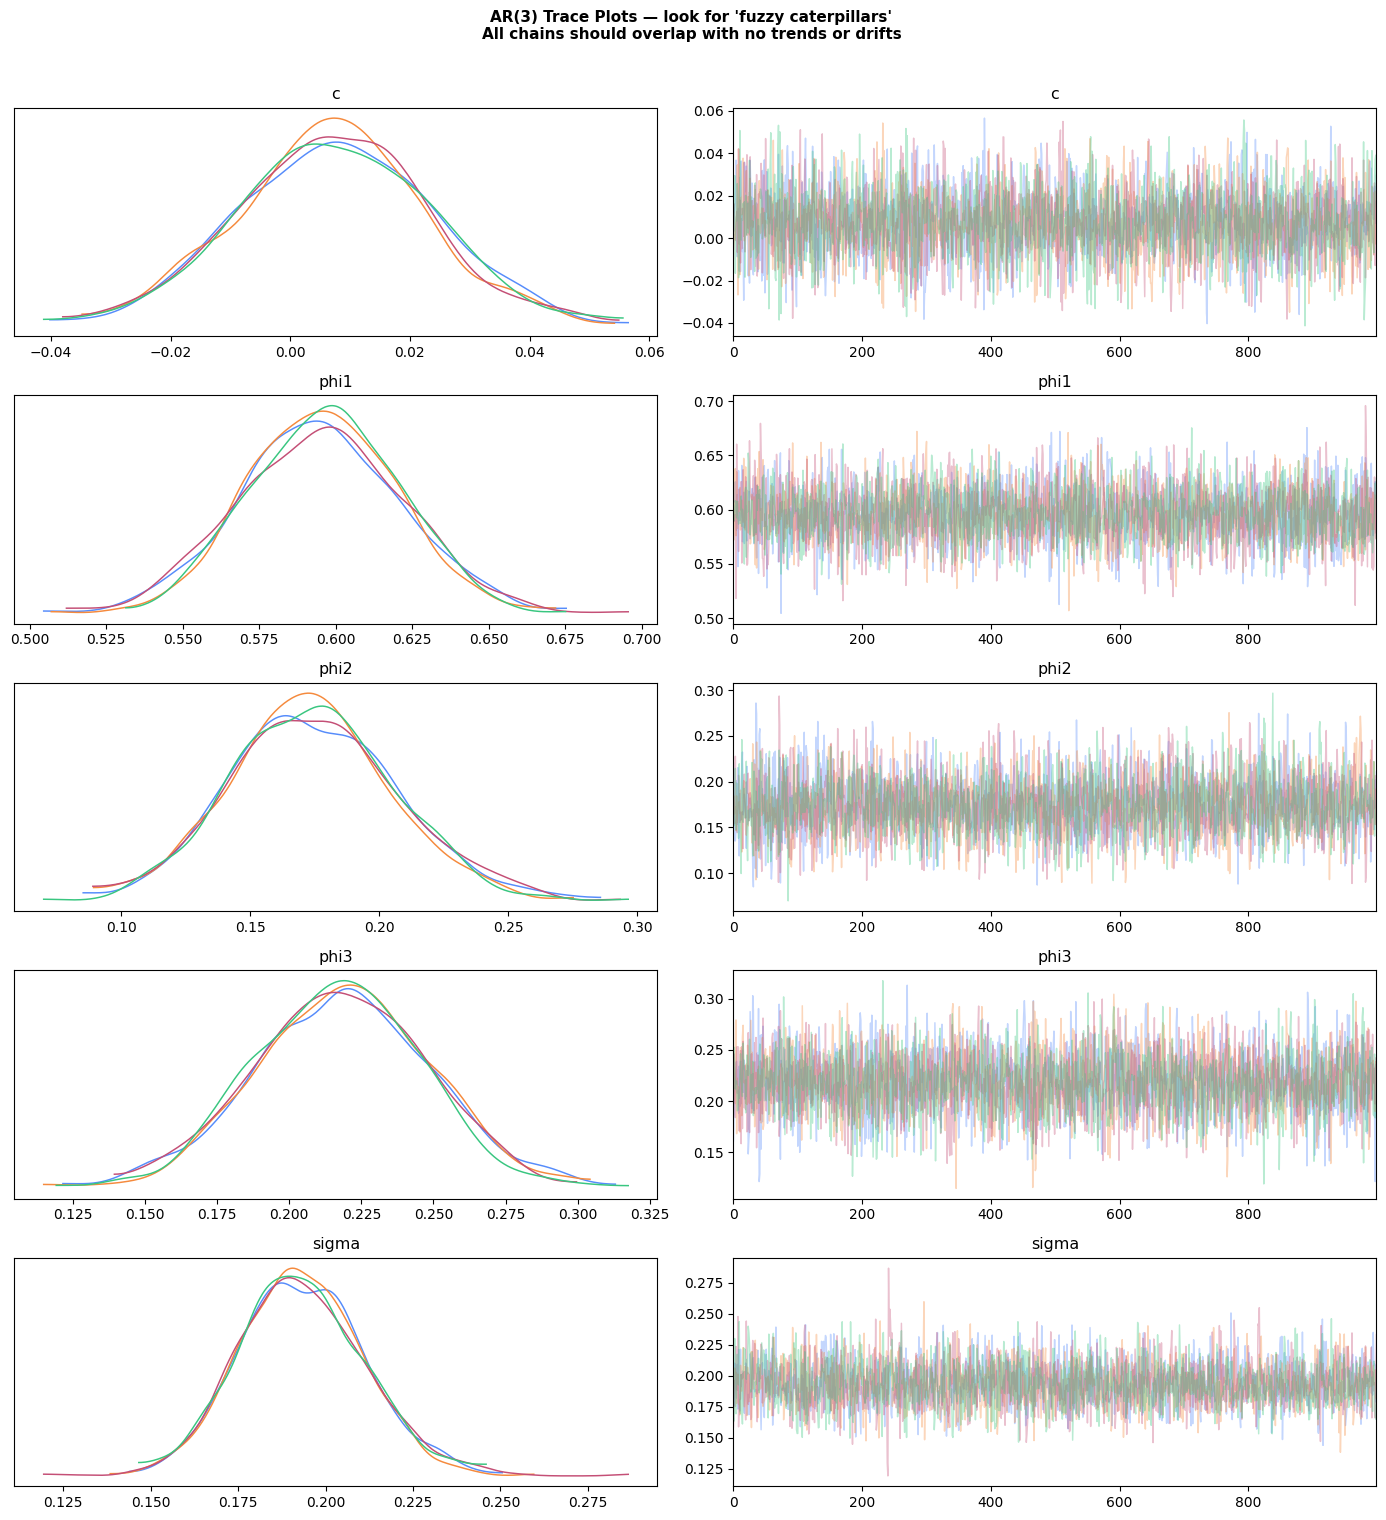

3. RANK PLOTS


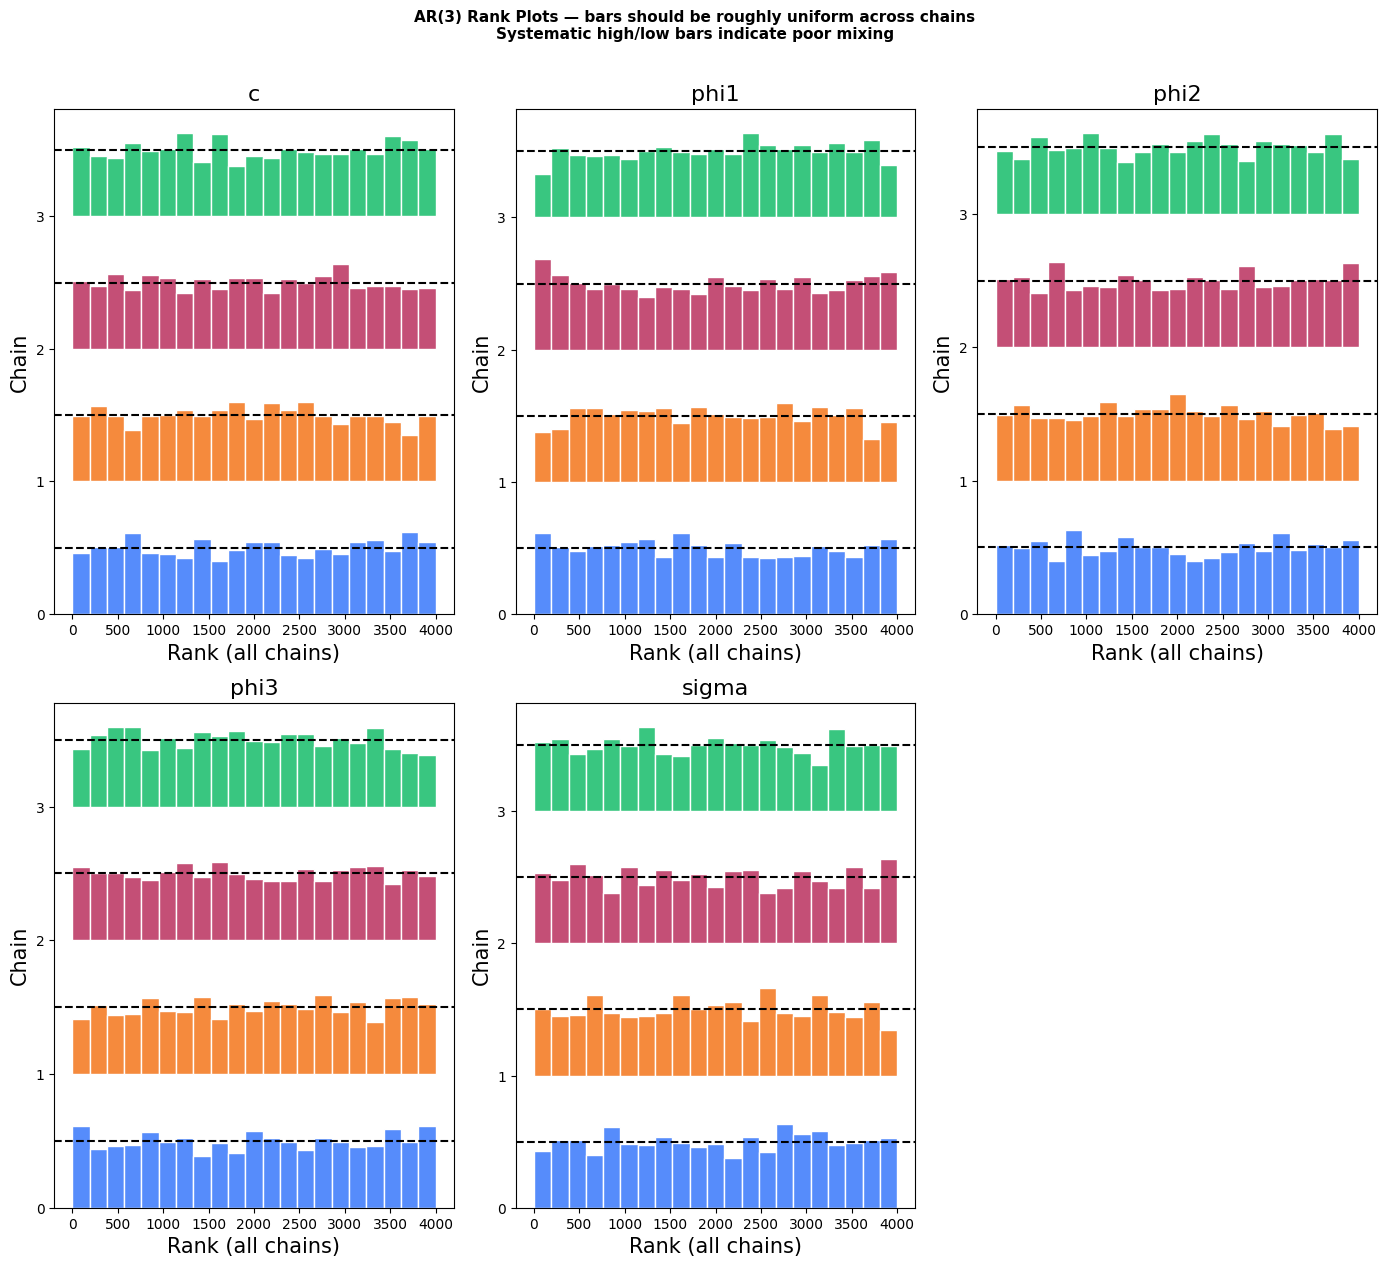

4. AUTOCORRELATION OF POSTERIOR DRAWS


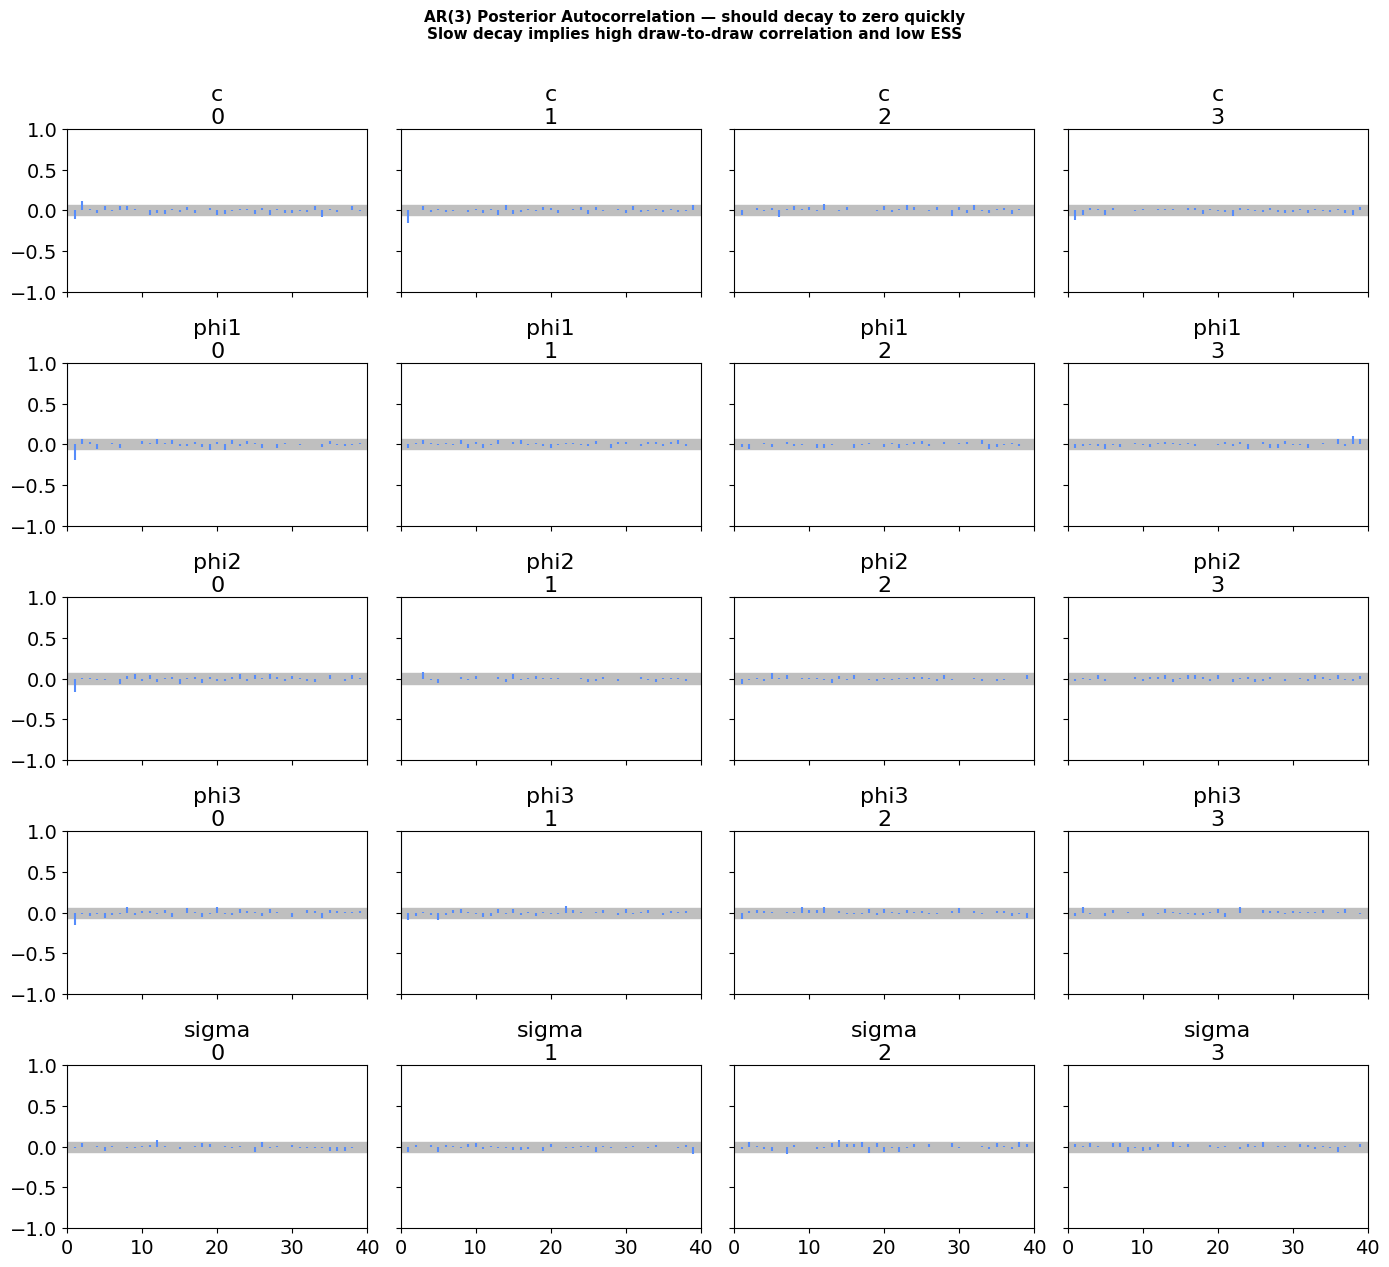

5. GEWEKE DIAGNOSTIC
  Parameter    Geweke z   Pass (|z|<1.96)
  ------------------------------------------
  c              0.3641                 ✓
  phi1          -1.1101                 ✓
  phi2           0.2984                 ✓
  phi3           0.3780                 ✓
  sigma          0.0744                 ✓

6. RUNNING MEAN PLOT — burn-in adequacy


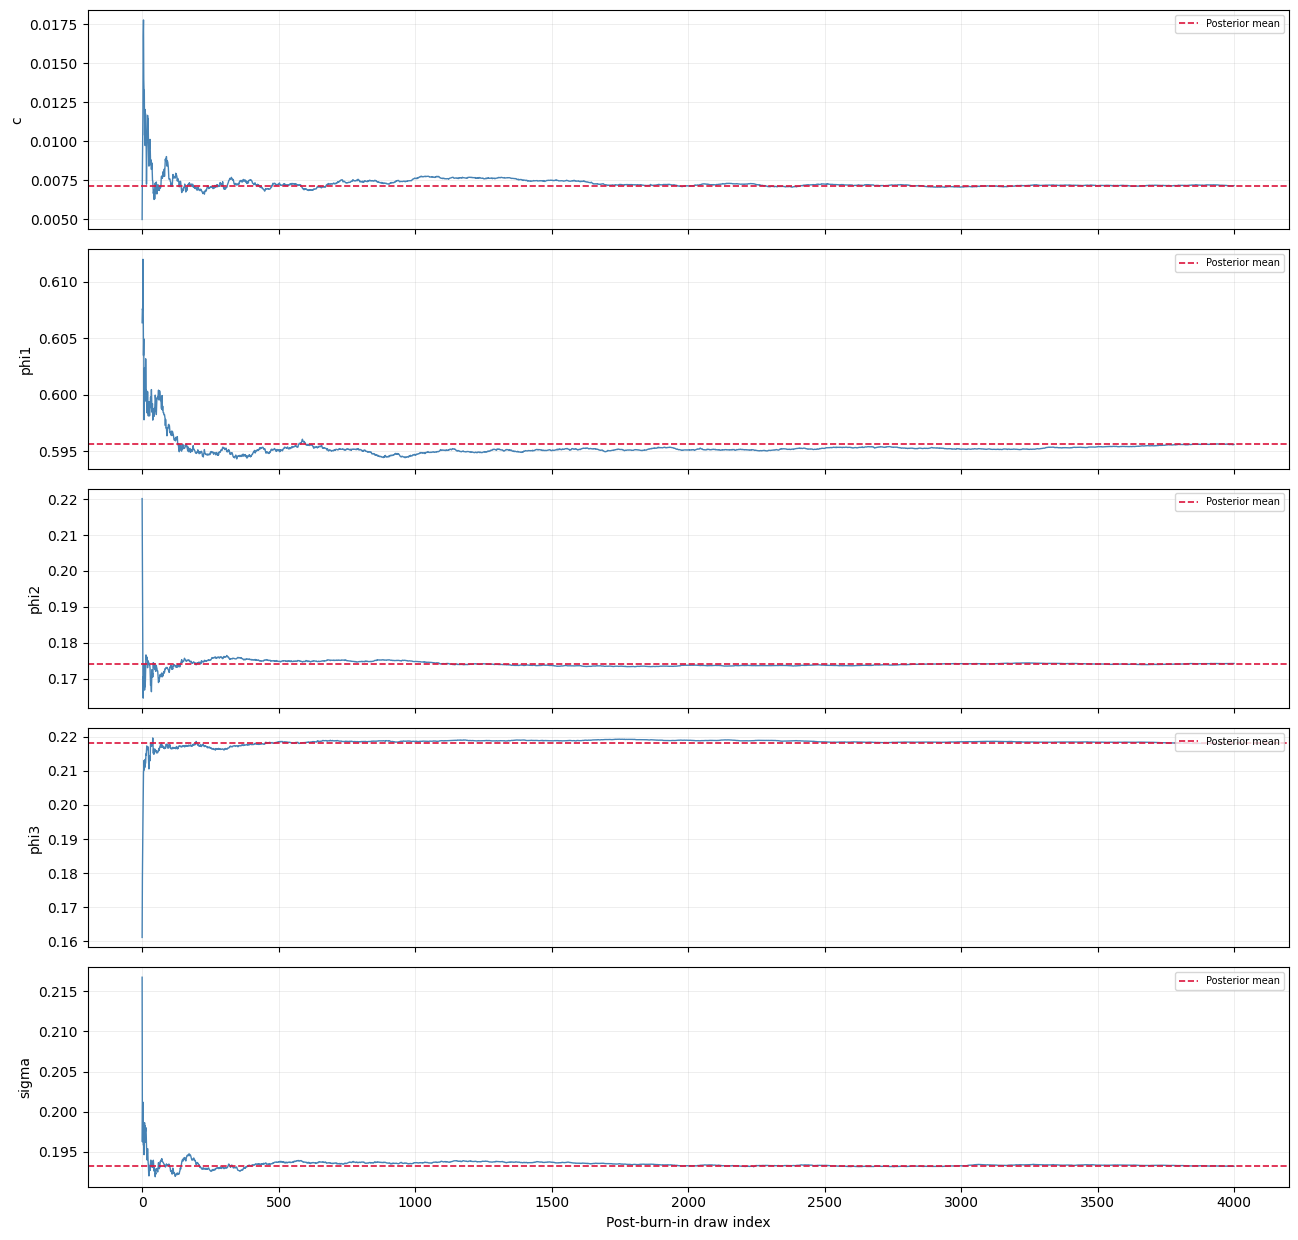

7. PAIR PLOT — posterior correlations between parameters


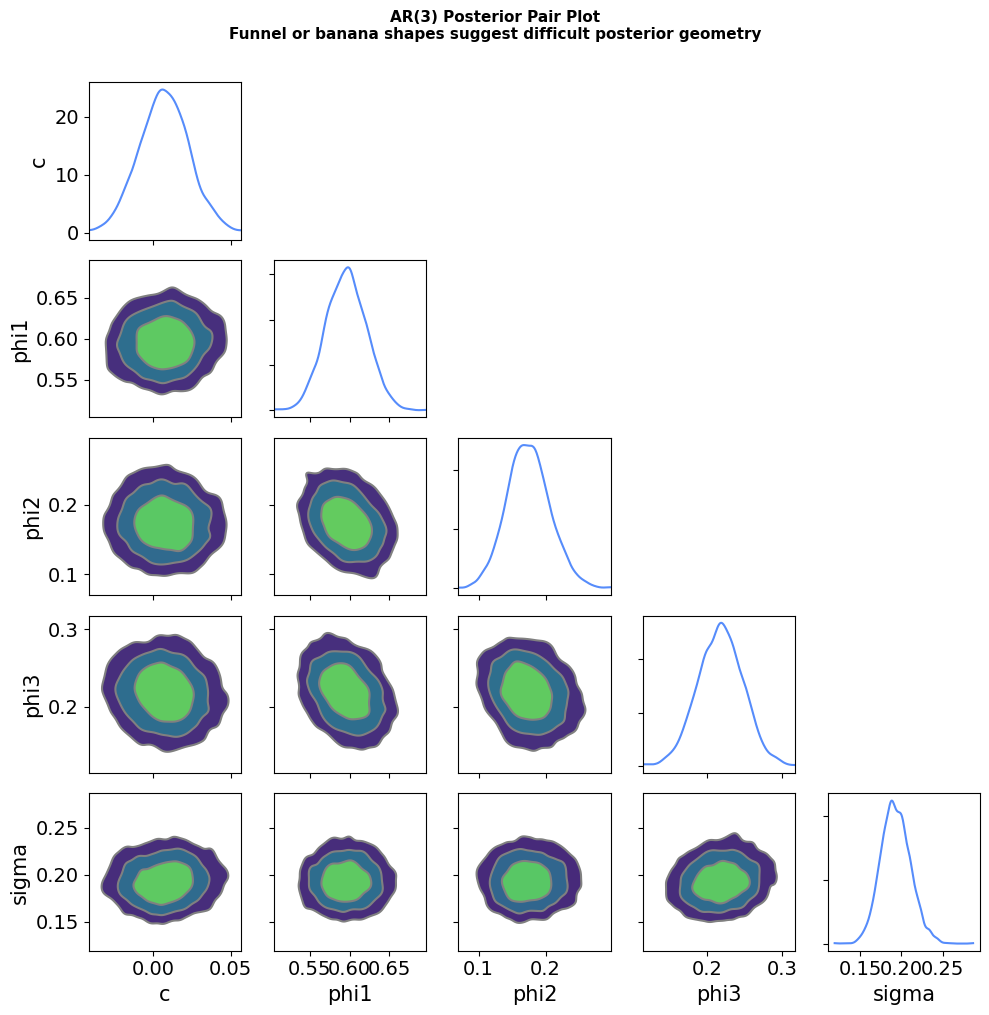

8. RESIDUAL DIAGNOSTICS — Ljung-Box on posterior mean residuals
     lb_stat  lb_pvalue
1     5.5690     0.0183
2     5.6803     0.0584
3    10.6596     0.0137
6    54.6494     0.0000
12   90.1011     0.0000
24  107.4829     0.0000

  p-values > 0.05 → residuals are white noise (good)
  ⚠ Significant autocorrelation at lags: [1, 3, 6, 12, 24]

CODA SUMMARY
  R-hat (max)    : 1.0035  ✓
  ESS (min)      : 3861    ✓
  Geweke (all)   : ✓ all passed
  Ljung-Box      : ⚠ autocorrelation present


In [20]:
# =============================================================================
# CODA CONVERGENCE DIAGNOSTICS — Bayesian AR(3) via PyMC / ArviZ
# =============================================================================
# Requires: idata_informed, phi1_draws, phi2_draws, phi3_draws,
#           c_draws, sigma_draws, resid_in
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from statsmodels.stats.diagnostic import acorr_ljungbox

var_names = ["c", "phi1", "phi2", "phi3", "sigma"]

# ── 1. R-hat and ESS via ArviZ ────────────────────────────────────────────────
print("=" * 60)
print("1. R-HAT AND EFFECTIVE SAMPLE SIZE")
print("=" * 60)
summary = az.summary(
    idata_informed,
    var_names=var_names,
    stat_focus="mean",
    round_to=4,
)
print(summary)

rhat_vals = summary["r_hat"].values
ess_vals  = summary["ess_bulk"].values

print(f"\n  Max R-hat  : {rhat_vals.max():.4f}  (threshold ≤ 1.01 strict, ≤ 1.05 lenient)")
print(f"  Min ESS    : {ess_vals.min():.0f}    (threshold ≥ 400 per chain)")

if rhat_vals.max() <= 1.01:
    print("  ✓ All R-hat values within acceptable range")
else:
    failed = summary[summary["r_hat"] > 1.01]["r_hat"]
    print(f"  ⚠ Parameters with R-hat > 1.01:\n{failed}")

if ess_vals.min() >= 400:
    print("  ✓ All ESS values above threshold")
else:
    failed_ess = summary[summary["ess_bulk"] < 400]["ess_bulk"]
    print(f"  ⚠ Parameters with ESS < 400:\n{failed_ess}")

# ── 2. Trace plots ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. TRACE PLOTS")
print("=" * 60)
az.plot_trace(
    idata_informed,
    var_names=var_names,
    compact=False,
    figsize=(14, 3 * len(var_names)),
)
plt.suptitle(
    "AR(3) Trace Plots — look for 'fuzzy caterpillars'\n"
    "All chains should overlap with no trends or drifts",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── 3. Rank plots (more sensitive than trace plots for subtle issues) ──────────
print("=" * 60)
print("3. RANK PLOTS")
print("=" * 60)
az.plot_rank(
    idata_informed,
    var_names=var_names,
    figsize=(14, 2.5 * len(var_names)),
)
plt.suptitle(
    "AR(3) Rank Plots — bars should be roughly uniform across chains\n"
    "Systematic high/low bars indicate poor mixing",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── 4. Autocorrelation plots ───────────────────────────────────────────────────
print("=" * 60)
print("4. AUTOCORRELATION OF POSTERIOR DRAWS")
print("=" * 60)
az.plot_autocorr(
    idata_informed,
    var_names=var_names,
    max_lag=40,
    figsize=(14, 2.5 * len(var_names)),
)
plt.suptitle(
    "AR(3) Posterior Autocorrelation — should decay to zero quickly\n"
    "Slow decay implies high draw-to-draw correlation and low ESS",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── 5. Geweke test ────────────────────────────────────────────────────────────
print("=" * 60)
print("5. GEWEKE DIAGNOSTIC")
print("=" * 60)

def geweke_z(chain, first=0.1, last=0.5):
    """Z-score comparing mean of first 10% vs last 50% of a single chain."""
    n = len(chain)
    a = chain[:int(first * n)]
    b = chain[int((1 - last) * n):]
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    return (a.mean() - b.mean()) / se if se > 0 else 0.0

draws_dict = {
    "c":     c_draws,
    "phi1":  phi1_draws,
    "phi2":  phi2_draws,
    "phi3":  phi3_draws,
    "sigma": sigma_draws,
}

print(f"  {'Parameter':<10} {'Geweke z':>10}  {'Pass (|z|<1.96)':>16}")
print("  " + "-" * 42)
for name, draws in draws_dict.items():
    z = geweke_z(draws)
    status = "✓" if abs(z) < 1.96 else "⚠ FAIL"
    print(f"  {name:<10} {z:>10.4f}  {status:>16}")

# ── 6. Running mean plot ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("6. RUNNING MEAN PLOT — burn-in adequacy")
print("=" * 60)

fig, axes = plt.subplots(len(draws_dict), 1,
                          figsize=(13, 2.5 * len(draws_dict)), sharex=True)

for ax, (name, draws) in zip(axes, draws_dict.items()):
    running_mean = np.cumsum(draws) / np.arange(1, len(draws) + 1)
    ax.plot(running_mean, color="steelblue", lw=1.0)
    ax.axhline(draws.mean(), color="crimson", lw=1.2, ls="--", label="Posterior mean")
    ax.set_ylabel(name)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Post-burn-in draw index")
plt.tight_layout()
plt.show()

# ── 7. Posterior pair plot — check for funnel-shaped correlations ─────────────
print("=" * 60)
print("7. PAIR PLOT — posterior correlations between parameters")
print("=" * 60)
az.plot_pair(
    idata_informed,
    var_names=var_names,
    kind="kde",
    marginals=True,
    figsize=(10, 10),
)
plt.suptitle(
    "AR(3) Posterior Pair Plot\n"
    "Funnel or banana shapes suggest difficult posterior geometry",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── 8. Residual white-noise check ─────────────────────────────────────────────
print("=" * 60)
print("8. RESIDUAL DIAGNOSTICS — Ljung-Box on posterior mean residuals")
print("=" * 60)
lb = acorr_ljungbox(resid_in, lags=[1, 2, 3, 6, 12, 24], return_df=True)
print(lb.round(4))
print("\n  p-values > 0.05 → residuals are white noise (good)")
if (lb["lb_pvalue"] > 0.05).all():
    print("  ✓ No significant autocorrelation detected in residuals")
else:
    failed_lags = lb[lb["lb_pvalue"] <= 0.05].index.tolist()
    print(f"  ⚠ Significant autocorrelation at lags: {failed_lags}")

print("\n" + "=" * 60)
print("CODA SUMMARY")
print("=" * 60)
print(f"  R-hat (max)    : {rhat_vals.max():.4f}  {'✓' if rhat_vals.max() <= 1.05 else '⚠'}")
print(f"  ESS (min)      : {ess_vals.min():.0f}    {'✓' if ess_vals.min() >= 400 else '⚠'}")
all_geweke = [abs(geweke_z(d)) < 1.96 for d in draws_dict.values()]
print(f"  Geweke (all)   : {'✓ all passed' if all(all_geweke) else '⚠ some failed'}")
lb_ok = (lb["lb_pvalue"] > 0.05).all()
print(f"  Ljung-Box      : {'✓ white noise' if lb_ok else '⚠ autocorrelation present'}")